In [36]:
'''# Iris Flower Classification Using Machine Learning

## Machine Learning Fundamentals

### Project Objective

#This project demonstrates the basic Machine Learning workflow using Python and Scikit-learn.

#The objective is to train a Machine Learning model to classify Iris flowers into three species:

- Setosa
- Versicolor
- Virginica

### Machine Learning Workflow

1. Import required libraries
2. Load the Iris dataset
3. Explore the dataset
4. Check for missing values
5. Visualize the data
6. Prepare features and target
7. Split the dataset into training and testing sets
8. Scale the features
9. Train a K-Nearest Neighbors (KNN) model
10. Make predictions
11. Evaluate the model
12. Create a confusion matrix
13. Test the model with new flower measurements'''

'# Iris Flower Classification Using Machine Learning\n\n## Machine Learning Fundamentals\n\n### Project Objective\n\n#This project demonstrates the basic Machine Learning workflow using Python and Scikit-learn.\n\n#The objective is to train a Machine Learning model to classify Iris flowers into three species:\n\n- Setosa\n- Versicolor\n- Virginica\n\n### Machine Learning Workflow\n\n1. Import required libraries\n2. Load the Iris dataset\n3. Explore the dataset\n4. Check for missing values\n5. Visualize the data\n6. Prepare features and target\n7. Split the dataset into training and testing sets\n8. Scale the features\n9. Train a K-Nearest Neighbors (KNN) model\n10. Make predictions\n11. Evaluate the model\n12. Create a confusion matrix\n13. Test the model with new flower measurements'

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [22]:
# Load the Iris dataset
iris = load_iris()

# Create a DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add target column
df["target"] = iris.target

# Add species names
df["species"] = df["target"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

print("Iris dataset loaded successfully!")
print(f"Dataset contains {df.shape[0]} samples and {df.shape[1]} columns.")

Iris dataset loaded successfully!
Dataset contains 150 samples and 6 columns.


In [23]:
print("First five rows:")
display(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nDataset information:")
df.info()

print("\nClass distribution:")
print(df["species"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

print("\nStatistical summary:")
display(df.describe())

First five rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa



Dataset shape:
(150, 6)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

Statistical summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


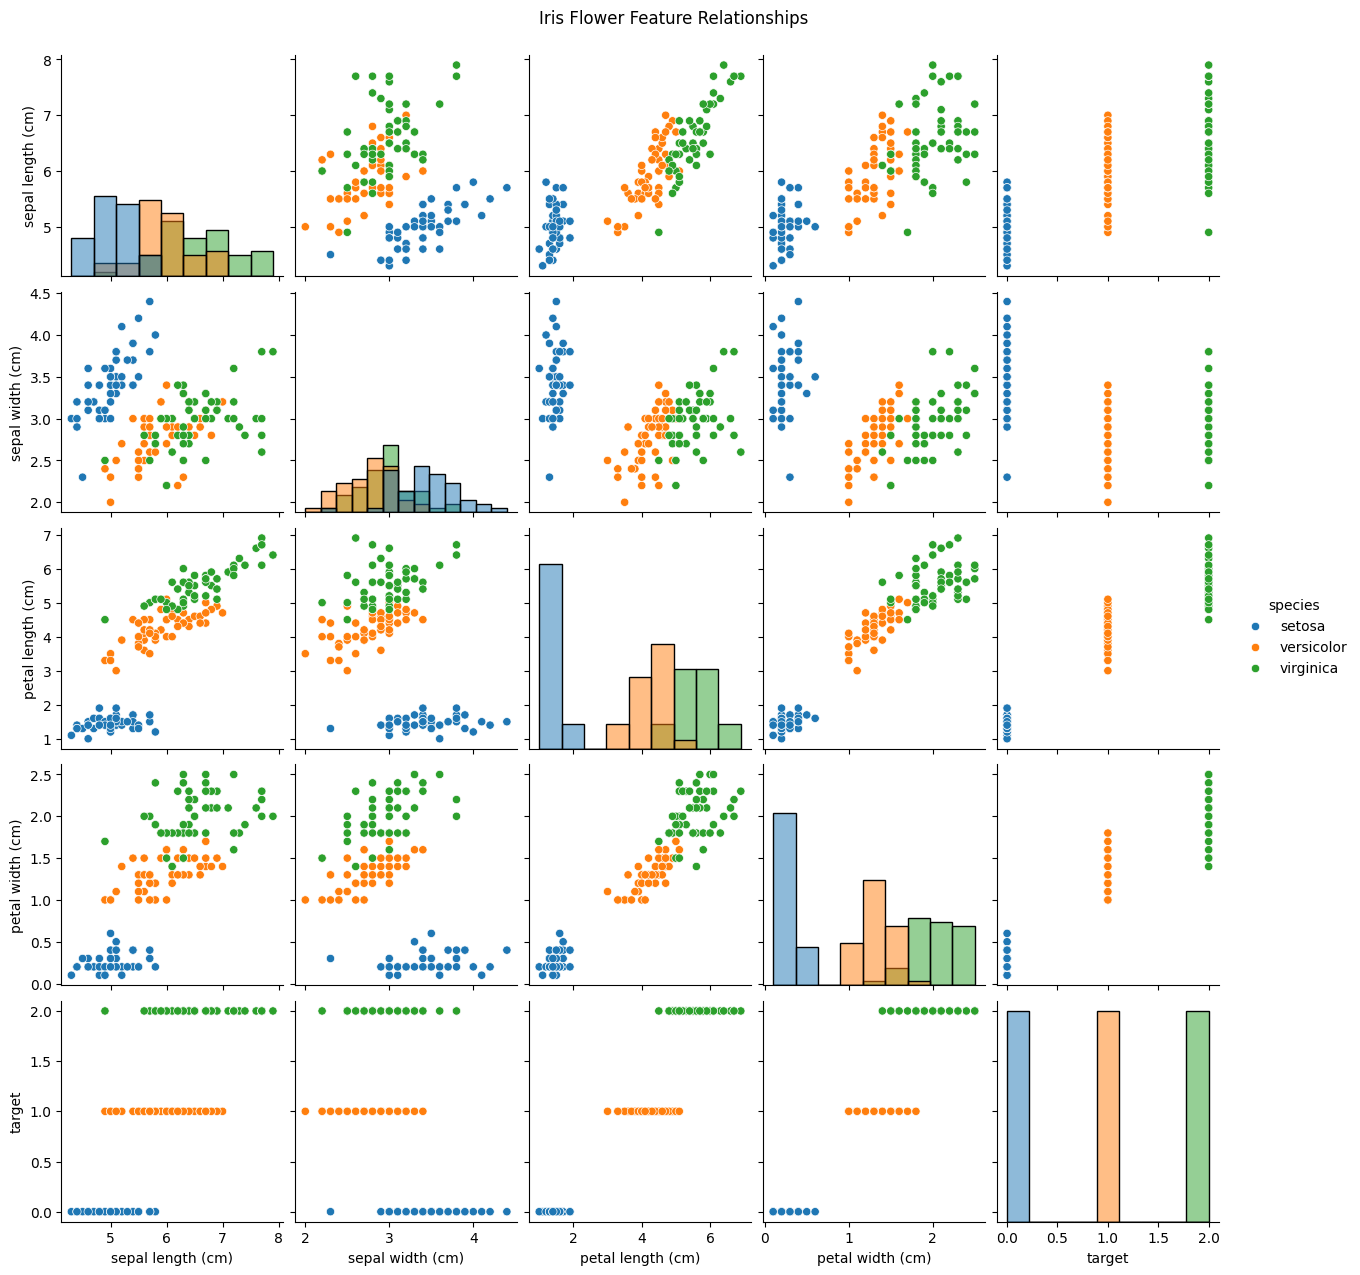

In [24]:
## Data Visualization

#Visualization helps us understand the relationship between the different features of Iris flowers.
# Pairplot of Iris features

sns.pairplot(
    df,
    hue="species",
    diag_kind="hist"
)

plt.suptitle(
    "Iris Flower Feature Relationships",
    y=1.02
)

plt.show()

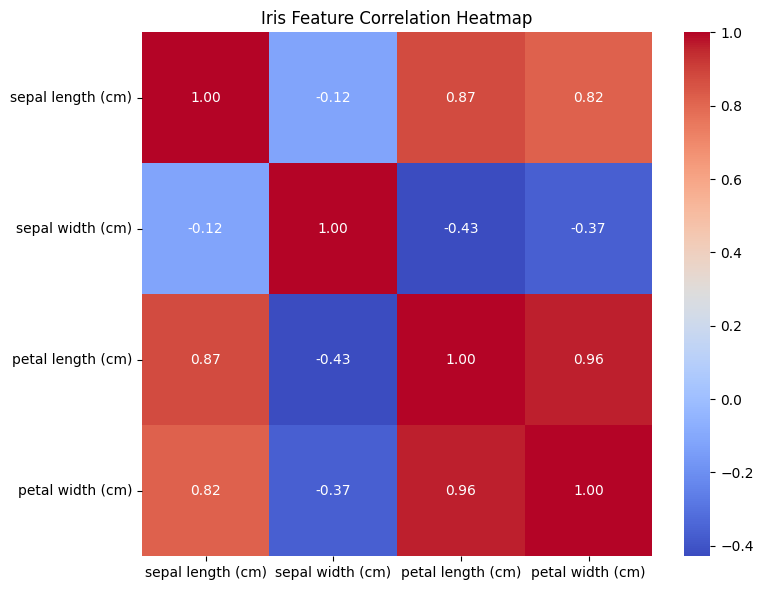

In [25]:
## Feature Correlation

#A correlation heatmap helps us understand how strongly the numerical features are related to each other.
# Calculate correlation

correlation = df[iris.feature_names].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Iris Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [26]:
## Feature and Target Preparation

#The input features are the flower measurements, while the target represents the flower species.
# Features
X = df[iris.feature_names]

# Target
y = df["target"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Target:


,target
0,0
1,0
2,0
3,0
4,0


In [27]:
## Train-Test Split

"The dataset is divided into training and testing sets."

"- 80% of the data is used for training."
"- 20% of the data is used for testing."
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


In [28]:
## Feature Scaling

#Feature scaling puts the numerical features on a similar scale before training the KNN model.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [29]:
## Model Training

#We use the K-Nearest Neighbors (KNN) algorithm to classify the Iris flowers.

#KNN predicts the class of a new sample based on the classes of its nearest neighboring samples.

# Create KNN model
model = KNeighborsClassifier(n_neighbors=5)

# Train the model
model.fit(X_train_scaled, y_train)

print("KNN model trained successfully!")

KNN model trained successfully!


In [30]:
## Model Predictions

#The trained model is now used to predict the species of the flowers in the testing dataset.

y_pred = model.predict(X_test_scaled)

print("Predictions:")
print(y_pred)

Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 1 1 0 2 0]


In [31]:
## Model Evaluation

#Accuracy measures the percentage of test samples that were classified correctly.

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


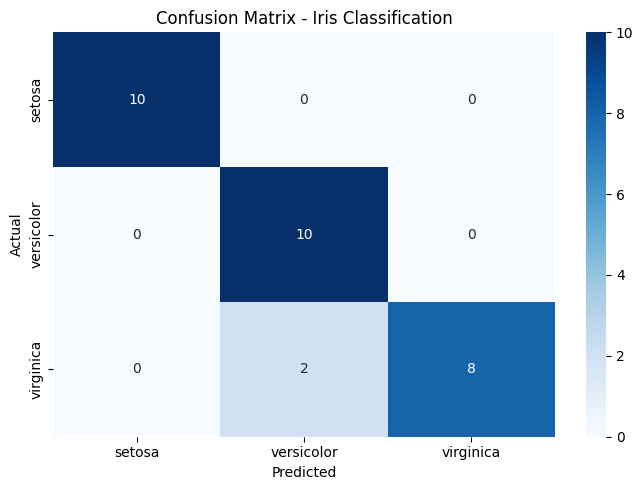

In [32]:
## Confusion Matrix

#A confusion matrix shows how many samples were correctly and incorrectly classified for each Iris species.

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Iris Classification")

plt.tight_layout()
plt.show()


In [33]:
## Predict a New Iris Flower

#We will provide measurements of a new flower and ask the trained model to predict its species.

# New flower measurements
new_flower = np.array([
    [5.1, 3.5, 1.4, 0.2]
])

# Scale the new data
new_flower_scaled = scaler.transform(new_flower)

# Predict
prediction = model.predict(new_flower_scaled)

# Convert prediction to species name
predicted_species = iris.target_names[prediction[0]]

print("New flower measurements:")
print(new_flower)

print("\nPredicted species:", predicted_species)

New flower measurements:
[[5.1 3.5 1.4 0.2]]

Predicted species: setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [34]:
probabilities = model.predict_proba(new_flower_scaled)

print("Prediction probabilities:\n")

for species, probability in zip(
    iris.target_names,
    probabilities[0]
):
    print(f"{species}: {probability * 100:.2f}%")

Prediction probabilities:

setosa: 100.00%
versicolor: 0.00%
virginica: 0.00%


In [37]:
'''# Conclusion

The Iris Flower Classification project successfully demonstrated a complete Machine Learning workflow using Python and Scikit-learn.

The project included:

- Dataset loading
- Data exploration
- Missing-value checking
- Statistical analysis
- Data visualization
- Feature and target preparation
- Train-test splitting
- Feature scaling
- K-Nearest Neighbors model training
- Predictions
- Model accuracy evaluation
- Classification report
- Confusion matrix
- Prediction of a new flower

The trained KNN model achieved a high classification accuracy on the test dataset, demonstrating that the Iris dataset can be effectively classified using Machine Learning.'''


'# Conclusion\n\nThe Iris Flower Classification project successfully demonstrated a complete Machine Learning workflow using Python and Scikit-learn.\n\nThe project included:\n\n- Dataset loading\n- Data exploration\n- Missing-value checking\n- Statistical analysis\n- Data visualization\n- Feature and target preparation\n- Train-test splitting\n- Feature scaling\n- K-Nearest Neighbors model training\n- Predictions\n- Model accuracy evaluation\n- Classification report\n- Confusion matrix\n- Prediction of a new flower\n\nThe trained KNN model achieved a high classification accuracy on the test dataset, demonstrating that the Iris dataset can be effectively classified using Machine Learning.'